## Datenbereinigung

In [47]:
#relevante Packages importieren
import pandas as pd 
import numpy as np
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
import itertools
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore')


In [48]:
# Datensatz einlesen
%pip install openpyxl

df_masterprojekt1 = pd.read_excel(
    'data/KIDEM_Datensatz_final_final.xlsx',
    sheet_name=0,
    header=0
)


Note: you may need to restart the kernel to use updated packages.


In [49]:
pd.set_option('display.max_columns', None)  # zeigt alle Spalten
# pd.set_option('display.expand_frame_repr', False)
df_masterprojekt1.head(5)

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,CH01_01,ID01_RV1,IN02_CP,IN02,PA01_01,PA01_02,PA01_03,PA01_04,PA01_05,PA01_06,PA01_07,PA02_01,PA02_02,PA02_03,PA02_04,PA02_05,PA02_06,PA02_07,PA02_08,PA02_09,PA02_10,PA02_11,PA02_12,PA03_01,PA03_02,PA03_03,PA03_04,PA03_05,PA03_06,PA03_07,PA03_08,PA03_09,PA04,PA05_01,PA05_02,PA06_01,PA06_02,PA06_03,PA06_04,PA06_05,PA06_06,PA06_07,PA06_08,PA06_09,PA06_10,PA07_01,PA07_02,PA07_03,PA07_04,PA08_01,PA08_02,PA08_03,PA08_04,PA08_05,PA08_06,PA08_07,PA08_08,PA08_09,PA08_10,PA08_11,PA08_12,PA09_01,PA09_02,PA09_03,PA09_04,PA10_01,PA10_02,PA10_03,PA10_04,PA11_01,PA11_02,PA11_03,PA11_04,PA12_01,PA12_02,PA12_03,PA12_04,PA12_05,PA12_06,PA12_07,PA12_08,PC01,PC02,PC03_01,PC03_02,PC03_03,PC03_04,PC03_05,PC03_06,PC03_07,PC03_08,PC04,PT01_01,PT01_01a,PT02,PT03,PT04_01,PT04_02,PT05_01,PT05_02,PT05_03,PT05_04,PT06_01,PT06_02,PT06_04,PT06_06,PT06_07,PT06_08,PT07,PT08,PT09_01,PT09_02,QA01_01,QA01_02,QA01_03,TE02,TE03_01,TR02,TIME001,TIME003,TIME004,TIME005,TIME006,TIME007,TIME008,TIME009,TIME010,TIME011,TIME012,TIME014,TIME015,TIME016,TIME017,TIME018,TIME019,TIME020,TIME021,TIME022,TIME023,TIME024,TIME025,TIME026,TIME027,TIME028,TIME029,TIME030,TIME031,TIME032,TIME033,TIME034,TIME035,TIME036,TIME037,TIME038,TIME039,TIME040,TIME041,TIME042,TIME043,TIME044,TIME045,TIME046,TIME_SUM,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI,TIME_CHAT_sec,TIME_CHAT_min,refugee_attitude,refugee_attitude_binary_contra,refugee_attitude_certainty,treatment,reactance_freedom_threat_mean,reactance_affect_mean,PA03_01_rev,PA03_03_rev,PA03_04_rev,reactance_cognition_mean,PA07_01_rev,PA07_04_rev,compromise_mean,countermobilization_mean,self_silencing_mean,ai_silencing_mean,outgroup_silencing_mean,PA12_03_rev,PA12_04_rev,PA12_05_rev,PA12_06_rev,PA12_07_rev,PA12_08_rev,political_tolerance_mean,PT06_02_rev,ambiguity_tolerance_mean,PA06_09_rev,PA06_10_rev,outgroup_emotion_mean,PT05_04_rev,ai_attitude_mean,ai_familiarity_mean,affective_polarization,LENGTH_CHAT,Index_kognegativ
0,917,NaN,NaN,base,1,2025-11-11 13:28:59,chatbot: Hallo! Wir wollen heute über eine Obe...,2___64d975959dbad50dd863691108ba17fd_VWGSIKKB,2,3,4,4,6,6,5,4,3,3,6,3,3,2,6,7,1,3,6,6,4,2,6,6,4,3,3,5,4,5,6,6,6,6.0,4.0,3.0,5.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,5.0,4.0,6.0,3.0,2.0,5.0,1.0,1.0,4.0,3.0,6.0,7.0,7.0,2.0,5.0,5.0,5.0,5.0,6.0,NaN,NaN,NaN,NaN,3.0,3.0,6.0,7.0,4.0,2.0,2.0,3.0,5.0,3.0,5.0,4.0,3.0,6.0,2.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,NaN,1989,0,2,6,4,6,6.0,2.0,3.0,6.0,6.0,5.0,NaN,NaN,6.0,7.0,6,5,NaN,NaN,2.0,2.0,3.0,Ja. Ich möchte das Gespräch mit dem Chatbot zu...,Test,"Ja, ich möchte das Gespräch mit dem Chatbot zu...",3,9,NaN,NaN,13,14,35,14,4,13,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,432.0,NaN,NaN,NaN,18,36,13,6.0,18,NaN,14,5,16.0,13.0,7.0,4.0,8.0,2.0,44.0,19.0,4.0,11.0,4.0,794,#NULL!,2025-11-11 13:42:13,NaN,1,0,46,46,0,0,1.78,0,0.000000,2,2,5,4,4.75,5.00,6.0,2.0,4.0,4.666667,5.0,2.0,4.000000,3.833333,5.25,NaN,4.750000,6.0,5.0,3.0,5.0,3.0,4.0,4.000000,3.0,5.500000,NaN,NaN,4.333333,2.0,3.250000,5.0,0,3413,4.666667
1,928,NaN,NaN,base,1,2025-11-11 14:57:18,chatbot: Hallo! Wir wollen heute über eine Obe...,2___2be2d4ea5b33ba812782617e2b20104f_VWGSIKKB,3,6,3,5,6,5,4,4,4,6,6,3,3,4,3,7,1,3,3,4,3,6,6,1,2,2,3,4,4,5,5,4,5,4.0,6.0,4.0,4.0,5.0,5.0,4.0,4.0,5.0,4.0,3.0,5.0,4.0,NaN,1.0,4.0,1.0,1.0,1.0,1.0,6.0,4.0,4.0,1.0,1.0,4.0,2.0,2.0,3.0,4.0,6.0,5.0,4.0,5.0,6.0,4.0,3.0,3.0,4.0,3.0,5.0,3.0,5.0,3.0,5.0,5.0,4.0,5.0,5.0,1.0,1.0,1.0,4.0,2.0,2.0,1.0,2.0,1964,0,2,6,1,3,5.0,NaN,NaN,5.0,4.0,5.0,4.0,5.0,5.0,4.0,6,5,NaN,NaN,2.0,3.0,3.0,Ja. Ich möchte das Gespräch mit dem Chatbot zu...,NaN,NaN,8,22,NaN,NaN,8,14,26,7,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,704.0,21.0,36.0,34,5,21,NaN,33,28.0,30,16,18.0,24.0,28.0,5.0,10.0,28.0,4.0,15.0,2.0,NaN,NaN,1152,#NULL!,2025-11-11 15:16:32,NaN,1,0,44,44,1,0,1.62,0,0.000000,2,2,5,1,3.25,4.75,2.0,7.0,6.0,5.000000,5.0,NaN,4.666667,2.416667,2.75,5.00,4.000000,3.0,5.0,3.0,5.0,3.0,3.0,3.625000,3.0,4.166667,3.0,4.0,4.

In [50]:
# kurzer Check, ob alle Fälle importiert wurden
n_faelle = len(df_masterprojekt1)
print(f"Anzahl Fälle (Zeilen): {n_faelle}")

print(f"Anzahl Spalten: {df_masterprojekt1.shape[1]}")



Anzahl Fälle (Zeilen): 645
Anzahl Spalten: 216


In [51]:
# Test: Häufigkeiten der Werte ausgeben lassen (Check, ob wir NaNs oder ungültige Werte haben)

df_masterprojekt1['PA03_01'].value_counts(dropna=False)

PA03_01
1    198
2    139
4    115
3     98
5     58
6     25
7     12
Name: count, dtype: int64

In [52]:
df_masterprojekt1['IN02'].value_counts(dropna=False)

IN02
6    112
3    110
4    108
1    107
2    107
5    101
Name: count, dtype: int64

In [53]:
# Gruppen zusammenfassen (Kommunikationsstile)

# 1+4=faktenbasiert, 2+5=gemischt, 3+6=empathisch
in02_num = pd.to_numeric(df_masterprojekt1['IN02'], errors='coerce')
_map = {1: 'faktenbasiert', 4: 'faktenbasiert',
        2: 'gemischt',     5: 'gemischt',
        3: 'empathisch',   6: 'empathisch'}
df_masterprojekt1['IN02_new'] = in02_num.map(_map)

df_masterprojekt1['IN02_new'].value_counts(dropna=False)

IN02_new
empathisch       222
faktenbasiert    215
gemischt         208
Name: count, dtype: int64

In [54]:
# Dichotome Dummyvariablen für Kommunikationsstile erstellen
in02_num = pd.to_numeric(df_masterprojekt1['IN02'], errors='coerce')
map_dummyvariablen = {
    1: 'faktenbasiert',
    4: 'faktenbasiert',
    2: 'gemischt',
    5: 'gemischt',
    3: 'empathisch',
    6: 'empathisch'
}
df_masterprojekt1['IN02_new'] = in02_num.map(map_dummyvariablen)

df_masterprojekt1['faktenbasiert_dich'] = (df_masterprojekt1['IN02_new'] == 'faktenbasiert').astype(int)
df_masterprojekt1['empathisch_dich'] = (df_masterprojekt1['IN02_new'] == 'empathisch').astype(int)
df_masterprojekt1['gemischt_dich'] = (df_masterprojekt1['IN02_new'] == 'gemischt').astype(int)

#Kontrolle

df_masterprojekt1[['IN02', 'IN02_new', 'faktenbasiert_dich', 'gemischt_dich', 'empathisch_dich']].head(10)


,IN02,IN02_new,faktenbasiert_dich,gemischt_dich,empathisch_dich
0,3,empathisch,0,0,1
1,6,empathisch,0,0,1
2,3,empathisch,0,0,1
3,3,empathisch,0,0,1
4,4,faktenbasiert,1,0,0
5,6,empathisch,0,0,1
6,6,empathisch,0,0,1
7,5,gemischt,0,1,0
8,1,faktenbasiert,1,0,0
9,2,gemischt,0,1,0


#### Items umpolen (sodass höhere Werte "mehr" bedeuten)

In [55]:
# PA01_05 positive Emotionen
df_masterprojekt1['PA01_05_inv'] = 8 - df_masterprojekt1['PA01_05']

# Check
df_masterprojekt1[['PA01_05', 'PA01_05_inv']].head(10)


,PA01_05,PA01_05_inv
0,5,3
1,4,4
2,5,3
3,4,4
4,7,1
5,4,4
6,5,3
7,3,5
8,4,4
9,4,4


In [56]:
# PA01_06: positive Emotionen
df_masterprojekt1['PA01_06_inv'] = 8 - df_masterprojekt1['PA01_06']

# Check
df_masterprojekt1[['PA01_06', 'PA01_06_inv']].head(10)

,PA01_06,PA01_06_inv
0,4,4
1,4,4
2,1,7
3,4,4
4,4,4
5,1,7
6,2,6
7,3,5
8,4,4
9,1,7


In [57]:
# PA01_07: positive Emotionen
df_masterprojekt1['PA01_07_inv'] = 8 - df_masterprojekt1['PA01_07']

# Check
df_masterprojekt1[['PA01_07', 'PA01_07_inv']].head(10)

,PA01_07,PA01_07_inv
0,3,5
1,4,4
2,2,6
3,5,3
4,4,4
5,1,7
6,3,5
7,4,4
8,3,5
9,1,7


In [58]:
# PA03_01 invertieren (7-stufig)
df_masterprojekt1['PA03_01_inv'] = 8 - df_masterprojekt1['PA03_01']

# Check
df_masterprojekt1[['PA03_01', 'PA03_01_inv']].head(10)

,PA03_01,PA03_01_inv
0,2,6
1,6,2
2,3,5
3,4,4
4,4,4
5,3,5
6,1,7
7,1,7
8,3,5
9,2,6


In [59]:
# PA03_03 invertieren (7-stufig)
df_masterprojekt1['PA03_03_inv'] = 8 - df_masterprojekt1['PA03_03']

# Check
df_masterprojekt1[['PA03_03', 'PA03_03_inv']].head(4)

,PA03_03,PA03_03_inv
0,6,2
1,1,7
2,2,6
3,4,4


In [60]:
# PA03_07 invertieren

df_masterprojekt1['PA03_07_inv'] = 8 - df_masterprojekt1['PA03_07']

# Check
df_masterprojekt1[['PA03_07', 'PA03_07_inv']].head(4)

,PA03_07,PA03_07_inv
0,5,3
1,4,4
2,4,4
3,4,4


In [61]:
# PA03_08 invertieren

df_masterprojekt1['PA03_08_inv'] = 8 - df_masterprojekt1['PA03_08']

# Check
df_masterprojekt1[['PA03_08', 'PA03_08_inv']].head(4)

,PA03_08,PA03_08_inv
0,4,4
1,4,4
2,2,6
3,4,4


In [62]:
# PA03_09 invertieren

df_masterprojekt1['PA03_09_inv'] = 8 - df_masterprojekt1['PA03_09']

# Check
df_masterprojekt1[['PA03_09', 'PA03_09_inv']].head(4)

,PA03_09,PA03_09_inv
0,5,3
1,5,3
2,3,5
3,5,3


In [63]:
# Affektive Polarisierung berechnen
# Differenz zwischen PA05_01 und PA05_02

df_masterprojekt1["affektive_polarisierung"] = (
    df_masterprojekt1["PA05_01"] - df_masterprojekt1["PA05_02"]
).abs() #abs steht für den absoluten Unterschied

# Kontrolltabelle mit den beiden Items und dem neuen Index
check_AP = df_masterprojekt1[["PA05_01", "PA05_02", "affektive_polarisierung"]]
print(check_AP.head(10))

   PA05_01  PA05_02  affektive_polarisierung
0        6        6                        0
1        4        5                        1
2        8        6                        2
3        8        4                        4
4       11        1                       10
5        5        8                        3
6        9        3                        6
7        3       11                        8
8        5        7                        2
9       10        3                        7


#### Mittelwertindizes bilden

In [64]:
# Vertrauen + wahrgenommene Authentizität
# Reliabilität checken (Cronachs Alpha)

# Auswahl der Variablen

items = ["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv"]
reliability_H2 = df_masterprojekt1[items].dropna()

def cronbach_alpha(reliability_H2):
    k = reliability_H2.shape[1]
    item_var = reliability_H2.var(axis=0, ddof=1)
    total_var = reliability_H2.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha = cronbach_alpha(reliability_H2)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

for col in reliability_H2.columns:
    alpha_del = cronbach_alpha(reliability_H2.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.841
Alpha ohne PA03_04: 0.817
Alpha ohne PA03_05: 0.841
Alpha ohne PA03_06: 0.801
Alpha ohne PA03_07_inv: 0.816
Alpha ohne PA03_08_inv: 0.813
Alpha ohne PA03_09_inv: 0.801


In [65]:
# Mittelwertindex (Vertrauen + wahrgenommene Authentizität)

df_masterprojekt1["index_vertauth"] = df_masterprojekt1[["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_vertauth"].describe())
df_masterprojekt1[["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv", "index_vertauth"]].head()

count    645.000000
mean       3.481654
std        1.301198
min        1.000000
25%        2.500000
50%        3.500000
75%        4.333333
max        7.000000
Name: index_vertauth, dtype: float64


,PA03_04,PA03_05,PA03_06,PA03_07_inv,PA03_08_inv,PA03_09_inv,index_vertauth
0,4,3,3,3,4,3,3.333333
1,2,2,3,4,4,3,3.000000
2,3,3,5,4,6,5,4.333333
3,4,4,4,4,4,3,3.833333
4,4,1,4,1,4,4,3.000000


In [66]:
# Reliabilität: wahrgenommene Freiheitseinschränkung

# Auswahl der Variablen
items = ["PA02_09", "PA02_10", "PA02_11", "PA02_12"]
reliability_einschraenkung = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_einschraenkung):
    k = reliability_einschraenkung.shape[1]
    item_var = reliability_einschraenkung.var(axis=0, ddof=1)
    total_var = reliability_einschraenkung.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_einschraenkung)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_einschraenkung.columns:
    alpha_del = cronbach_alpha(reliability_einschraenkung.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")


Cronbachs Alpha gesamt: 0.862
Alpha ohne PA02_09: 0.836
Alpha ohne PA02_10: 0.843
Alpha ohne PA02_11: 0.810
Alpha ohne PA02_12: 0.804


In [67]:
# Mittelwertindex: wahrgenommene Freiheitseinschränkung
df_masterprojekt1["index_freiheitseinschraenkung"] = df_masterprojekt1[["PA02_09", "PA02_10", "PA02_11", "PA02_12"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_freiheitseinschraenkung"].describe())
df_masterprojekt1[["PA02_09", "PA02_10", "PA02_11", "PA02_12", "index_freiheitseinschraenkung"]].head(5)


count    645.000000
mean       3.296512
std        1.674957
min        1.000000
25%        1.750000
50%        3.250000
75%        4.500000
max        7.000000
Name: index_freiheitseinschraenkung, dtype: float64


,PA02_09,PA02_10,PA02_11,PA02_12,index_freiheitseinschraenkung
0,3,6,6,4,4.75
1,3,3,4,3,3.25
2,3,3,4,4,3.50
3,4,4,4,4,4.00
4,5,5,4,6,5.00


In [68]:
# affektive Reaktanz-Dimension

# Auswahl der Variablen
items = ["PA01_01", "PA01_02", "PA01_03", "PA01_04", "PA01_05_inv", "PA01_06_inv", "PA01_07_inv"]
reliability_affreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_affreaktanz):
    k = reliability_affreaktanz.shape[1]
    item_var = reliability_affreaktanz.var(axis=0, ddof=1)
    total_var = reliability_affreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_affreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_affreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_affreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.896
Alpha ohne PA01_01: 0.865
Alpha ohne PA01_02: 0.876
Alpha ohne PA01_03: 0.868
Alpha ohne PA01_04: 0.867
Alpha ohne PA01_05_inv: 0.881
Alpha ohne PA01_06_inv: 0.900
Alpha ohne PA01_07_inv: 0.902


In [69]:
# affektive Reaktanz-Dimension (negative Emotionen)

# Auswahl der Variablen
items = ["PA01_01", "PA01_02", "PA01_03", "PA01_04"]
reliability_affreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_affreaktanz):
    k = reliability_affreaktanz.shape[1]
    item_var = reliability_affreaktanz.var(axis=0, ddof=1)
    total_var = reliability_affreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_affreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_affreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_affreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.936
Alpha ohne PA01_01: 0.904
Alpha ohne PA01_02: 0.927
Alpha ohne PA01_03: 0.928
Alpha ohne PA01_04: 0.905


In [70]:
# Mittelwertindex: affektive Reaktanz-Dimension

df_masterprojekt1["index_affreaktanz"] = df_masterprojekt1[["PA01_01", "PA01_02", "PA01_03", "PA01_04"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_affreaktanz"].describe())
df_masterprojekt1[["PA01_01", "PA01_02", "PA01_03", "PA01_04", "index_affreaktanz", "reactance_affect_mean"]].head()

count    645.000000
mean       3.277907
std        1.821306
min        1.000000
25%        1.500000
50%        3.250000
75%        4.500000
max        7.000000
Name: index_affreaktanz, dtype: float64


,PA01_01,PA01_02,PA01_03,PA01_04,index_affreaktanz,reactance_affect_mean
0,4,4,6,6,5.00,5.00
1,3,5,6,5,4.75,4.75
2,2,2,3,3,2.50,2.50
3,4,4,4,4,4.00,4.00
4,4,4,4,4,4.00,4.00


In [71]:
# kognitive Reaktanz-Dimension

# Auswahl der Variablen
items = ["PA03_01_inv", "PA03_02", "PA03_03_inv"]
reliability_kogreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_kogreaktanz):
    k = reliability_kogreaktanz.shape[1]
    item_var = reliability_kogreaktanz.var(axis=0, ddof=1)
    total_var = reliability_kogreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_kogreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_kogreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_kogreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.681
Alpha ohne PA03_01_inv: 0.461
Alpha ohne PA03_02: 0.767
Alpha ohne PA03_03_inv: 0.545


In [72]:
# Mittelwertindex: kognitive Reaktanz-Dimension

df_masterprojekt1["index_kogreaktanz"] = df_masterprojekt1[["PA03_01_inv", "PA03_02", "PA03_03_inv"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_kogreaktanz"].describe())
df_masterprojekt1[["PA03_01_inv", "PA03_02", "PA03_03_inv", "index_kogreaktanz", "reactance_cognition_mean"]].head()

count    645.000000
mean       5.041860
std        1.299442
min        1.000000
25%        4.000000
50%        5.000000
75%        6.000000
max        7.000000
Name: index_kogreaktanz, dtype: float64


,PA03_01_inv,PA03_02,PA03_03_inv,index_kogreaktanz,reactance_cognition_mean
0,6,6,2,4.666667,4.666667
1,2,6,7,5.000000,5.000000
2,5,4,6,5.000000,5.000000
3,4,4,4,4.000000,4.000000
4,4,5,7,5.333333,5.333333


In [73]:
# Reaktanz

# Auswahl der Variablen
items = ["PA03_01_inv", "PA03_02", "PA03_03_inv", 
         "PA01_01", "PA01_02", "PA01_03", "PA01_04", 
         "PA02_09", "PA02_10", "PA02_11", "PA02_12"]
reliability_reaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_reaktanz):
    k = reliability_reaktanz.shape[1]
    item_var = reliability_reaktanz.var(axis=0, ddof=1)
    total_var = reliability_reaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_reaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_reaktanz.columns:
    alpha_del = cronbach_alpha(reliability_reaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")


Cronbachs Alpha gesamt: 0.910
Alpha ohne PA03_01_inv: 0.909
Alpha ohne PA03_02: 0.902
Alpha ohne PA03_03_inv: 0.913
Alpha ohne PA01_01: 0.896
Alpha ohne PA01_02: 0.900
Alpha ohne PA01_03: 0.895
Alpha ohne PA01_04: 0.896
Alpha ohne PA02_09: 0.904
Alpha ohne PA02_10: 0.906
Alpha ohne PA02_11: 0.898
Alpha ohne PA02_12: 0.900


In [74]:
# Mittelwertindex: Reaktanz

df_masterprojekt1["index_reaktanz"] = df_masterprojekt1[["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_reaktanz"].describe())
df_masterprojekt1[["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung", "index_reaktanz"]].head()

count    645.000000
mean       3.872093
std        1.352665
min        1.000000
25%        2.750000
50%        4.000000
75%        4.777778
max        7.000000
Name: index_reaktanz, dtype: float64


,index_affreaktanz,index_kogreaktanz,index_freiheitseinschraenkung,index_reaktanz
0,5.00,4.666667,4.75,4.805556
1,4.75,5.000000,3.25,4.333333
2,2.50,5.000000,3.50,3.666667
3,4.00,4.000000,4.00,4.000000
4,4.00,5.333333,5.00,4.777778


## Deskriptive Statistiken

### Geschlecht

          Absolute Häufigkeit  Relative Häufigkeit (%)
PT02                                                  
Männlich                  326                    50.54
Weiblich                  318                    49.30
Divers                      1                     0.16


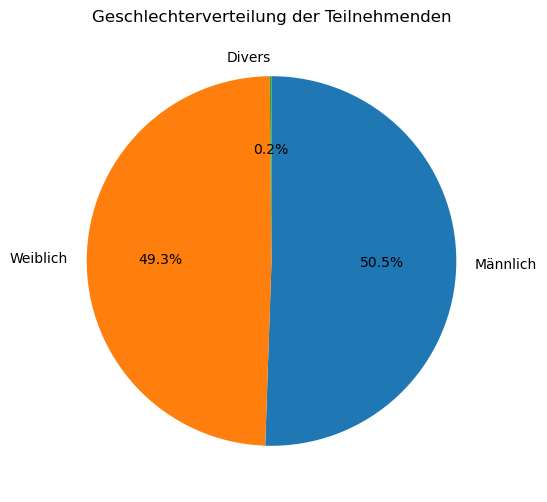

In [75]:
# Deskriptive Statistiken (Häufigkeiten prozentual und absolut) für PT02

absolute = df_masterprojekt1['PT02'].value_counts().sort_index()
relative = df_masterprojekt1['PT02'].value_counts(normalize=True).sort_index()

haeufigkeitstabelle = pd.DataFrame({
    'Absolute Häufigkeit': absolute,
    'Relative Häufigkeit (%)': (relative * 100).round(2)
})

haeufigkeitstabelle.index = haeufigkeitstabelle.index.map({1: 'Männlich', 2: 'Weiblich', 3: 'Divers'})
print(haeufigkeitstabelle)

# Kreisdiagramm

labels = ['Männlich', 'Weiblich', 'Divers']

plt.figure(figsize=(6, 6))
plt.pie(
    relative, 
    labels=labels, 
    autopct='%1.1f%%',   # Eine Nachkommastelle
    startangle=90,       # Startwinkel für schönere Ausrichtung
    counterclock=False   # damit das Diagramm im Uhrzeigersinn läuft
)

plt.title('Geschlechterverteilung der Teilnehmenden')
plt.show()


### Alter

In [76]:
# Zur Errechnung des Alters in Jahren: 2025 - Geburtstjahr PT01_01
df_masterprojekt1['PT01_01_new'] = 2025 - df_masterprojekt1['PT01_01']

# Kontrolle: erste Werte
df_masterprojekt1['PT01_01_new'].head()

0    36
1    61
2    35
3    47
4    69
Name: PT01_01_new, dtype: int64

In [77]:
# Deskriptive Statistiken (Mittelwert, Median, SD, Min, Max)

df_masterprojekt1['PT01_01_new'].describe()

count    645.000000
mean      44.582946
std       11.688026
min       18.000000
25%       35.000000
50%       44.000000
75%       53.000000
max       69.000000
Name: PT01_01_new, dtype: float64

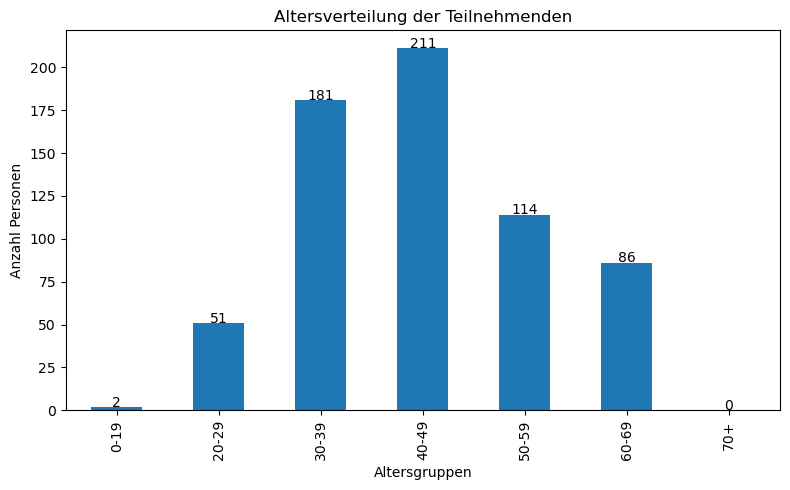

In [78]:
# Balkendiagramm Alterverteilung in Altersgruppen (0-19, 20-29, 30-39, 40-49, 50-59, 60-69, 70+)

# Altersgruppen definieren
bins = [0, 19, 29, 39, 49, 59, 69, 120]
labels = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

# Alterswerte in Gruppen einteilen
df_masterprojekt1['Altersgruppe'] = pd.cut(df_masterprojekt1['PT01_01_new'], bins=bins, labels=labels, right=True)

# Anzahl pro Gruppe zählen
altersverteilung = df_masterprojekt1['Altersgruppe'].value_counts().sort_index()

# Balkendiagramm erstellen
plt.figure(figsize=(8, 5))
altersverteilung.plot(kind='bar')

# Titel und Achsenbeschriftungen
plt.title('Altersverteilung der Teilnehmenden')
plt.xlabel('Altersgruppen')
plt.ylabel('Anzahl Personen')

# Werte auf den Balken anzeigen
for i, v in enumerate(altersverteilung):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()


### Höchster Bildungsabschluss

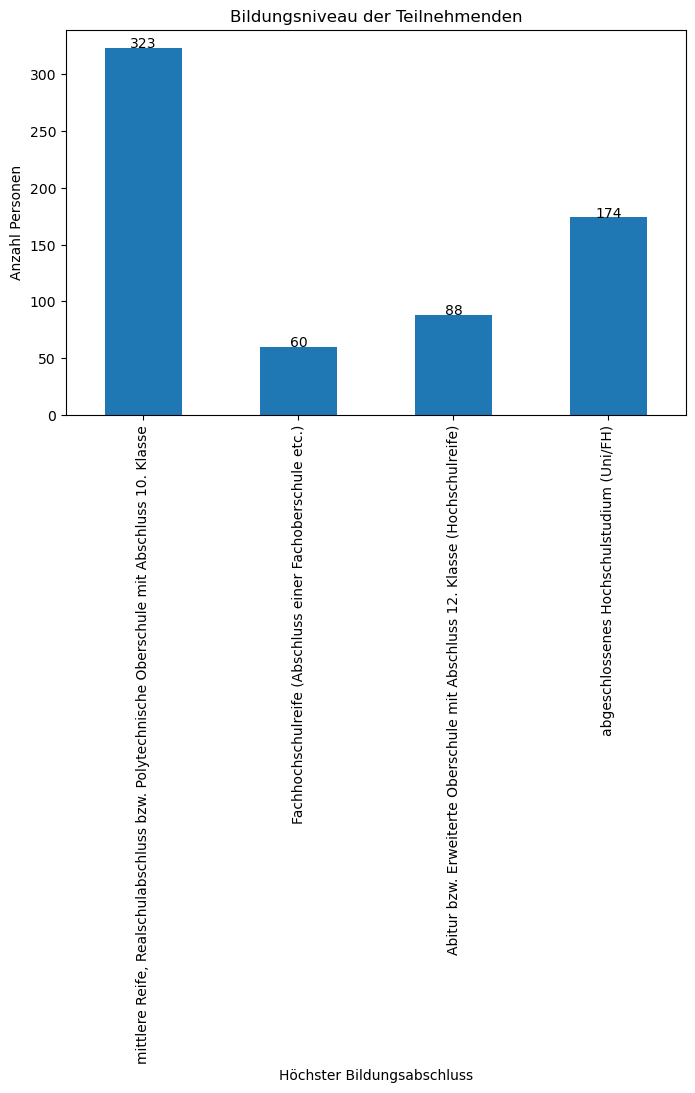

In [79]:
# Deskriptive Statistiken
df_masterprojekt1['PT03'].describe()

# Balkendiagramm erstellen
bildungsniveau = df_masterprojekt1['PT03'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
bildungsniveau.plot(kind='bar')

# Labels für Bildungsniveau – die Beschriftung könnte man evtl. nur kürzer formulieren
labels_bildung = {
    1: 'Schüler/-in, besuche eine allgemeinbildende Vollzeitschule',
    2: 'Volks- / Hauptschulabschluss bzw. Polytechnische Oberschule mit Abschluss 8. oder 9. Klasse',
    3: 'mittlere Reife, Realschulabschluss bzw. Polytechnische Oberschule mit Abschluss 10. Klasse',
    4: 'Fachhochschulreife (Abschluss einer Fachoberschule etc.)',
    5: 'Abitur bzw. Erweiterte Oberschule mit Abschluss 12. Klasse (Hochschulreife)',
    6: 'abgeschlossenes Hochschulstudium (Uni/FH)',
}

# Achsenbeschriftung mit Textlabels ersetzen
plt.xticks(ticks=range(len(bildungsniveau)),
           labels=[labels_bildung[i] for i in bildungsniveau.index],
           rotation=90)

# Titel und Achsenbeschriftungen
plt.title('Bildungsniveau der Teilnehmenden')
plt.xlabel('Höchster Bildungsabschluss')
plt.ylabel('Anzahl Personen')

# Werte auf den Balken anzeigen
for i, v in enumerate(bildungsniveau):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()


### Einstellung zur Obergenze

In [80]:
# Deskriptive Statistiken
df_masterprojekt1['PT07'].describe()

count    645.000000
mean       2.541085
std        1.740173
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        6.000000
Name: PT07, dtype: float64

In [81]:
# Einteilung in pro Obergrenze und contra Obergrenze – Werte von 01 bis 03 sind pro Obergrenze, 04 bis 06 contra Obergrenze

map_obergrenze = {
    1: 'pro Obergrenze',
    2: 'pro Obergrenze',
    3: 'pro Obergrenze',
    4: 'contra Obergrenze',
    5: 'contra Obergrenze',
    6: 'contra Obergrenze'
}
df_masterprojekt1['PT07_new'] = df_masterprojekt1['PT07'].map(map_obergrenze)

# Deskriptive Statistiken
df_masterprojekt1['PT07_new'].value_counts()

PT07_new
pro Obergrenze       473
contra Obergrenze    172
Name: count, dtype: int64

## Tests rechnen

### Manipulationscheck

In [82]:
# Mittelwertindex bilden: PA02_03, PA02_04 (empathisch)

df_masterprojekt1["index_check_empathisch"] = df_masterprojekt1[["PA02_03", "PA02_04"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_check_empathisch"].describe())
df_masterprojekt1[["PA02_03", "PA02_04", "index_check_empathisch"]].head(10)

count    645.000000
mean       3.653488
std        1.677539
min        1.000000
25%        2.500000
50%        3.500000
75%        5.000000
max        7.000000
Name: index_check_empathisch, dtype: float64


,PA02_03,PA02_04,index_check_empathisch
0,3,3,3.0
1,3,3,3.0
2,3,5,4.0
3,4,4,4.0
4,4,4,4.0
5,2,2,2.0
6,3,2,2.5
7,2,4,3.0
8,4,5,4.5
9,6,4,5.0


In [83]:
# Mittelwertindex bilden: PA02_05, PA02_06 (faktenbasiert)

df_masterprojekt1["index_check_faktenbasiert"] = df_masterprojekt1[["PA02_05", "PA02_06"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_check_faktenbasiert"].describe())
df_masterprojekt1[["PA02_05", "PA02_06", "index_check_faktenbasiert"]].head(10)

count    645.000000
mean       4.129457
std        1.591632
min        1.000000
25%        3.000000
50%        4.000000
75%        5.500000
max        7.000000
Name: index_check_faktenbasiert, dtype: float64


,PA02_05,PA02_06,index_check_faktenbasiert
0,2,6,4.0
1,4,3,3.5
2,3,6,4.5
3,4,5,4.5
4,4,4,4.0
5,4,4,4.0
6,2,3,2.5
7,3,4,3.5
8,5,5,5.0
9,1,4,2.5


In [84]:
# Mittelwertindex bilden: PA02_03, PA02_04, PA02_05, PA02_06 (gemischt)

df_masterprojekt1["index_check_gemischt"] = df_masterprojekt1[["PA02_03", "PA02_04","PA02_05", "PA02_06"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_check_gemischt"].describe())
df_masterprojekt1[["PA02_03", "PA02_04","PA02_05", "PA02_06", "index_check_gemischt"]].head(10)

count    645.000000
mean       3.891473
std        1.431757
min        1.000000
25%        3.000000
50%        4.000000
75%        4.750000
max        7.000000
Name: index_check_gemischt, dtype: float64


,PA02_03,PA02_04,PA02_05,PA02_06,index_check_gemischt
0,3,3,2,6,3.50
1,3,3,4,3,3.25
2,3,5,3,6,4.25
3,4,4,4,5,4.25
4,4,4,4,4,4.00
5,2,2,4,4,3.00
6,3,2,2,3,2.50
7,2,4,3,4,3.25
8,4,5,5,5,4.75
9,6,4,1,4,3.75


In [85]:
# Überprüfen mit dem Kommunikationsstil

print(df_masterprojekt1["index_check_gemischt"].describe())
df_masterprojekt1[["IN02_new","index_check_empathisch", "index_check_faktenbasiert", "index_check_gemischt"]].head(10)

count    645.000000
mean       3.891473
std        1.431757
min        1.000000
25%        3.000000
50%        4.000000
75%        4.750000
max        7.000000
Name: index_check_gemischt, dtype: float64


,IN02_new,index_check_empathisch,index_check_faktenbasiert,index_check_gemischt
0,empathisch,3.0,4.0,3.50
1,empathisch,3.0,3.5,3.25
2,empathisch,4.0,4.5,4.25
3,empathisch,4.0,4.5,4.25
4,faktenbasiert,4.0,4.0,4.00
5,empathisch,2.0,4.0,3.00
6,empathisch,2.5,2.5,2.50
7,gemischt,3.0,3.5,3.25
8,faktenbasiert,4.5,5.0,4.75
9,gemischt,5.0,2.5,3.75


In [123]:
def run_anova(df_manipulationscheck, av, title): # Definieren einer neuen Funktion, die jeweils drei Anovas durchführt; var steht für unsere abhängige Variable
    print(f"\n===== {title} =====\n") # dient lediglich der Übersichtlichkeit des Outputs; title = Überschrift für den Block

    df_manipulationscheck = df_manipulationscheck[[av, 'IN02_new']].dropna().copy() # Arbeitsdataframe, um die relevanten Spalten auszuwählen (av = Index)
    df_manipulationscheck['IN02_new'] = df_manipulationscheck['IN02_new'].astype('category') # Gruppierungsvariable als kategorial festlegen

    print("Deskriptive Werte:")
    print(df_manipulationscheck.groupby('IN02_new')[av].agg(['count','mean','std']), "\n") # gibt uns jeweils Anzahl, Mittelwert und Standardabweichung je Gruppe aus

    model = ols(f'{av} ~ C(IN02_new)', data=df_manipulationscheck).fit() # lineares Modell 8AV wird durch die kategoriale Variable IN02_new vorhergesagt)
    print("ANOVA:")
    print(anova_lm(model, typ=2), "\n") # Durchführen der Varianzanalyse

    groups = df_manipulationscheck['IN02_new'].cat.categories # Gruppen und Paarvergleiche (Post-hoc)
    pairs = list(it.combinations(groups, 2)) # Erzeugen aller 2er-Kombinationen (3 Paarvergleiche)

    results_manipulationscheck = []
    for g1, g2 in pairs: # Schleife über alle Gruppenpaare
        x = df_manipulationscheck.loc[df_manipulationscheck['IN02_new'] == g1, av]
        y = df_manipulationscheck.loc[df_manipulationscheck['IN02_new'] == g2, av]
        t, p = ttest_ind(x, y, equal_var=False)
        results_manipulationscheck.append([g1, g2, x.mean(), y.mean(), p]) # Speichern in einer Liste: Gruppenname, Mittelwerte, p-Wert

    results_manipulationscheck = pd.DataFrame(results_manipulationscheck, columns=['g1','g2','m1','m2','p_unc'])
    results_manipulationscheck['p_bonf'] = multipletests(results_manipulationscheck['p_unc'], method='bonferroni')[1]

    print("Post-hoc (Bonferroni):")
    print(results_manipulationscheck, "\n")


run_anova(df_masterprojekt1, "index_check_empathisch", "Block 1: Empathischer Manipulationscheck")
run_anova(df_masterprojekt1, "index_check_faktenbasiert", "Block 2: Faktenbasierter Manipulationscheck")
run_anova(df_masterprojekt1, "index_check_gemischt", "Block 3: Gemischter Manipulationscheck")




===== Block 1: Empathischer Manipulationscheck =====



KeyError: "['IN02_new'] not in index"

### Hypothese 1

In [86]:
# Hypothese 1a: Ein Gespräch mit einem LLM, das einen faktenbasierten KS verwendet, führt bei Befragten zu einer stärkeren affektiven Polarisierung als ein empathischer sowie ein gemischter KS.

# Hypothese 1b:Ein gemischter KS führt zu einer geringeren affektiven Polarisierung als ein empathischer sowie faktenbasierter KS.


import itertools as it # brauchen wir, um später Kombinationen von Gruppen zu erzeugen (Paarvergleiche)

# Daten 
df_anovaH1 = df_masterprojekt1[['affektive_polarisierung', 'IN02_new']].dropna() # Dataframe erstellen mit den beiden Variablen (AP & KS)
df_anovaH1['IN02_new'] = df_anovaH1['IN02_new'].astype('category') #Umwandlung der Variable IN02_new in einen kategorialen Datentyp

# Gruppenübersicht - zeigt die AP deskriptiv für jeden Kommunikationsstil
print(df_anovaH1.groupby('IN02_new')['affektive_polarisierung'].agg(['count','mean','std']))

# ANOVA (Haupteffekt)
modelH1 = ols('affektive_polarisierung ~ C(IN02_new)', data=df_anovaH1).fit() # erstellt ein lineares Modell (ols) mit der Av affektive_polarisierung und der UV IN02_new
print(anova_lm(modelH1, typ=2)) # Durchführen einer Varianzanalyse 

# Post-hoc (Welch) + Bonferroni
groupsH1 = df_anovaH1['IN02_new'].cat.categories.tolist() # holt alle Kategorien (empathisch, faktenbasiert, gemischt) als Liste
pairs = list(it.combinations(groupsH1, 2)) # Erstellen aller möglichen 2er-Kombinationen dieser Gruppen (paarweiser Vergleich)

results = []
for g1, g2 in pairs:
    x = df_anovaH1.loc[df_anovaH1['IN02_new'] == g1, 'affektive_polarisierung']
    y = df_anovaH1.loc[df_anovaH1['IN02_new'] == g2, 'affektive_polarisierung']
    t, p = ttest_ind(x, y, equal_var=False, nan_policy='omit')
    results.append({'g1': g1, 'g2': g2, 'n1': x.size, 'n2': y.size, # Gruppennamen g1, g2; Stichprobengröße n1, n2
                    'm1': x.mean(), 'm2': y.mean(), 't': t, 'p_unc': p}) # Mittelwerte m1, m2; t-Wert: t; unkorrekten p-Wert: p_unc

p_adj = multipletests([r['p_unc'] for r in results], method='bonferroni') # holt alle unkorrekten p-Werte und korrigiert sie nac Bonferroni
for r, p_b, sig in zip(results, p_adj[1], p_adj[0]):# Hinzufügen des korrigierten Ergebnisses
    r['p_bonf'] = p_b # Bonferroni-korrigierten p-Wert
    r['sig_bonf'] = sig #True/False, ob signifikant nach Bonferroni 


posthoc_df = pd.DataFrame(results).sort_values('p_bonf') # Ergebnistabelle 
print(posthoc_df[['g1','g2','n1','n2','m1','m2','t','p_unc','p_bonf','sig_bonf']].round(4)) 

               count      mean       std
IN02_new                                
empathisch       222  3.995495  3.311160
faktenbasiert    215  4.237209  3.335523
gemischt         208  4.028846  3.526180
                  sum_sq     df         F   PR(>F)
C(IN02_new)     7.413240    2.0  0.322545  0.72442
Residual     7377.724744  642.0       NaN      NaN
              g1             g2   n1   n2      m1      m2       t   p_unc  \
0     empathisch  faktenbasiert  222  215  3.9955  4.2372 -0.7601  0.4476   
1     empathisch       gemischt  222  208  3.9955  4.0288 -0.1009  0.9196   
2  faktenbasiert       gemischt  215  208  4.2372  4.0288  0.6239  0.5330   

   p_bonf  sig_bonf  
0     1.0     False  
1     1.0     False  
2     1.0     False  


 - Allgemein fällt auf, dass die Mittelwerte für die drei Bedingungen recht nah beieinander liegen -> keine inhaltlich bedeutsamen Unterschiede erkennbar
 
 - deskriptiv: Tendenziell etwas höhere affektive Polarisierung bei faktenbasiert und gemischt als bei empathisch, aber Streuung sehr hoch, besonders bei gemischt. (siehe mean & std)
 
 - F(2,642) = 0.32, p = 0.724 -> kein signifikanter Haupteffekt des Kommunikationsstils auf die affektive Polarisierung
 
 - Post-hoc-Vergleiche: keiner der drei Vergleiche ist signifikant (siehe p-Wert = 1.0 nach Bonferroni-Korrektur: p_bonf & 3mal False)

 - Interpretation: Der Kommunikationsstil hat keinen Einfluss auf die affektive Polarisierung. 

### Hypothese 2

In [87]:
# Hypothese H2:Je höher das Vertrauen in den Chatbot ausfällt, desto geringer ist die Reaktanz gegenüber dem Chatbot.
# Bivariate Korrelation - UV: Mittelwertindex Vertrauen + wahrgenommene Authentizität, AV: Mittelwertindex Reaktanz

colsH2 = ['index_vertauth', 'index_reaktanz'] # definiert die zwei Spaltennamen, die für die Korrelation verwendet werden
df_corr = df_masterprojekt1[colsH2].apply(pd.to_numeric, errors='coerce').dropna() # Zeilen mit fehlende Werten entfernen

x, y = df_corr['index_vertauth'], df_corr['index_reaktanz'] # Kurzvariablen anlegen für Vertrauen (x) und Reaktanz (y)

print(f"n = {len(df_corr)}") # Stichprobengröße
print(df_corr.describe().loc[['mean','std']].round(3)) # Deskriptive Statistik ausgeben (Mittelwert, Standardabweichung)

# Korrelationen
r_p, p_p = pearsonr(x, y) # Pearson-Korrelation, inkl. p-Wert
r_s, p_s = spearmanr(x, y) # Spearman-Korrelation, inkl.p-Wert

# kompakte Tabelle ausgeben
out = pd.DataFrame({
    'Test': ['Pearson (r)', 'Spearman (ρ)'],
    'Koeffizient': [r_p, r_s],
    'p-Wert': [p_p, p_s],
    'Richtung (H2 erwartet negativ)': ['negativ' if r_p < 0 else 'positiv',
                                       'negativ' if r_s < 0 else 'positiv']
}).round(4)
print("\nErgebnisse:\n", out.to_string(index=False))


n = 645
      index_vertauth  index_reaktanz
mean           3.482           3.872
std            1.301           1.353

Ergebnisse:
         Test  Koeffizient  p-Wert Richtung (H2 erwartet negativ)
 Pearson (r)      -0.7244     0.0                        negativ
Spearman (ρ)      -0.7190     0.0                        negativ


- deskriptiv: beide Variablen sind ungefähr im mittleren Bereich angesiedelt
- relativ große Streuungen 
- Pearson-Korrelation: sehr starker negativer Zusammenhang -> Je höher das Vertrauen, desto geringer die Reaktanz + hochsignifikant, denn p<.001 
- Die H2 kann angenommen werden, d.h. je höher das Vertrauen in den Chatbot, desto geringer die Reaktanz.

In [88]:
# bei Bedarf: detailliertere Analyse (multivariate Regression)
# AV 1: wahrgenommene Freiheitseinschränkung; AV 2: affektive Reaktanz-Dimension; AV 3: kognitive Reaktanz-Dimension

# Daten vorbereiten
cols_regression = ['index_vertauth', 'index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung'] # Liste definieren mit unserer UV und den drei AVs
df_regressionH2 = df_masterprojekt1[cols_regression].apply(pd.to_numeric, errors='coerce').dropna() # relevanten Spalten auswählen & alle Werte in Zahlen umwandeln

X = df_regressionH2['index_vertauth'] # unabhängige Variable - unseren Prädiktor Vertrauen+ wahrgenommene Authentizität erstellen
X = sm.add_constant(X)  # Konstante hinzufügen (Achsenabschnitt für die Regressionsgerade)

# Liste der AVs
avs = ['index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung']
av_namen = ['Affektive Reaktanz', 'Kognitive Reaktanz', 'Wahrgenommene Freiheitseinschränkung'] # lesbar für die ausgabe

print(f"Stichprobengröße: n = {len(df_regressionH2)}\n")
print("="*80) # Trennlinie (bessere Lesbarkeit)

# Schleife über alle drei Reaktanz-Dimensionen
for av, name in zip(avs, av_namen): # paralleles Durchlaufen der drei AVs
    print(f"\n### REGRESSION: {name} ###\n") # Überschrift für jede Regression
    
    y = df_regressionH2[av] # holt die aktuelle abhängige Variable aus dem DataFrame
    
    # Regression rechnen
    model = sm.OLS(y, X).fit() # OLS = Ordinary Least Squares (klassische lineare Regression)
    
    # Kompakte Ergebnistabelle
    resultsH2 = pd.DataFrame({
        'Koeffizient': model.params, # Regressionskoeffizienten (b1 = Steigung für Vertrauen)
        'SE': model.bse, # Standardfehler der Koeffizienten
        'β (standardisiert)': [0, stats.pearsonr(df_regressionH2['index_vertauth'], y)[0]],
        't-Wert': model.tvalues,
        'p-Wert': model.pvalues
    }).round(4)
    
    print(resultsH2)
    print(f"\nR² = {model.rsquared:.4f}") # Anteil der erklärten Variant
    print(f"Adj. R² = {model.rsquared_adj:.4f}") # korrigiertes R-Quadrat
    print(f"F-Statistik = {model.fvalue:.4f}, p = {model.f_pvalue:.4f}") # testen, ob das Gesamtmodell signifikant ist
    print(f"\nInterpretation: Pro Einheit mehr Vertrauen sinkt/steigt {name} um {model.params['index_vertauth']:.4f} Einheiten.")
    print("="*80)


Stichprobengröße: n = 645


### REGRESSION: Affektive Reaktanz ###

                Koeffizient      SE  β (standardisiert)   t-Wert  p-Wert
const                5.8603  0.1740              0.0000  33.6846     0.0
index_vertauth      -0.7417  0.0468             -0.5299 -15.8448     0.0

R² = 0.2808
Adj. R² = 0.2797
F-Statistik = 251.0576, p = 0.0000

Interpretation: Pro Einheit mehr Vertrauen sinkt/steigt Affektive Reaktanz um -0.7417 Einheiten.

### REGRESSION: Kognitive Reaktanz ###

                Koeffizient      SE  β (standardisiert)   t-Wert  p-Wert
const                7.6641  0.0961              0.0000  79.7402     0.0
index_vertauth      -0.7532  0.0259             -0.7542 -29.1233     0.0

R² = 0.5688
Adj. R² = 0.5681
F-Statistik = 848.1642, p = 0.0000

Interpretation: Pro Einheit mehr Vertrauen sinkt/steigt Kognitive Reaktanz um -0.7532 Einheiten.

### REGRESSION: Wahrgenommene Freiheitseinschränkung ###

                Koeffizient      SE  β (standardisiert)   t-Wert  p-

- Interpretation pro AV
    - Affektive Reaktanz: b = -0.742 -> Je höher das Vertrauen, desto geringer die affektive Reaktanz; beta = -0.53 (mittlerer bis starker Effekt); R^2 = 0.281 (Vertrauen erklärt 28% der Varianz) -> deutlicher negativer Zusammenhang
    - Kognitive Reaktanz: b = +0.743 -> Je höher das Vertrauen, desto höher die kognitive Reaktanz; beta = 0.754 (sehr starker positiver Effekt); R^2 = 0.569 (Vertrauen erklärt 57% der Varianz) -> stärkster Zusammenhang (*braucht noch eine Einordnung - Warum positiv?*)
    - Wahrgenommene Freiheitseinschränkung: b = -0.764 -> Je höher das Vertrauen, desto geringer die wahrgenommene Freiheitseinschränkung; beta = -0.594(starker Effekt); R^2 = 0.353 (Vertrauen erklärt 35% der Varianz) -> klarer negativer Zusammenhang (stärker als bei affektiver Reaktanz)

### Hypothese 3

In [91]:
# Die Beziehung zwischen dem KS eines Chatbots und der affektiven Polarisierung wird durch die Reaktanz mediierend beeinflusst, wenn das Vertrauen in den Chatbot kontrolliert wird.

# Dummyvariablen für den Kommunikationsstil (IN02_new) erstellen, falls noch nicht vorhanden
if 'IN02_new' in df_masterprojekt1.columns:
	df_masterprojekt1 = pd.get_dummies(df_masterprojekt1, columns=['IN02_new'], drop_first=True)
else:
	print("Dummyvariablen für IN02_new sind bereits vorhanden.")
print(df_masterprojekt1.columns)

Dummyvariablen für IN02_new sind bereits vorhanden.
Index(['CASE', 'SERIAL', 'REF', 'QUESTNNR', 'MODE', 'STARTED', 'CH01_01',
       'ID01_RV1', 'IN02_CP', 'IN02',
       ...
       'index_kogreaktanz', 'index_reaktanz', 'PT01_01_new', 'Altersgruppe',
       'PT07_new', 'index_check_empathisch', 'index_check_faktenbasiert',
       'index_check_gemischt', 'IN02_new_faktenbasiert', 'IN02_new_gemischt'],
      dtype='object', length=241)


In [120]:
# Überprüfen der Datentypen der relevanten Variablen

df_masterprojekt1[[
    "IN02_new_faktenbasiert",
    "IN02_new_gemischt",
    "index_reaktanz",
    "affektive_polarisierung",
    "index_vertauth"
]].dtypes

IN02_new_faktenbasiert       int64
IN02_new_gemischt            int64
index_reaktanz             float64
affektive_polarisierung      int64
index_vertauth             float64
dtype: object

In [121]:
# Überprüfen auf fehlende Werte in den relevanten Variablen

df_masterprojekt1[[
    "IN02_new_faktenbasiert",
    "IN02_new_gemischt",
    "index_reaktanz",
    "affektive_polarisierung",
    "index_vertauth"
]].isna().sum()

IN02_new_faktenbasiert     0
IN02_new_gemischt          0
index_reaktanz             0
affektive_polarisierung    0
index_vertauth             0
dtype: int64

In [115]:
df_masterprojekt1["IN02_new_faktenbasiert"] = df_masterprojekt1["IN02_new_faktenbasiert"].astype(int)
df_masterprojekt1["IN02_new_gemischt"] = df_masterprojekt1["IN02_new_gemischt"].astype(int)


In [116]:
df_masterprojekt1[["IN02_new_faktenbasiert", "IN02_new_gemischt"]].dtypes


IN02_new_faktenbasiert    int64
IN02_new_gemischt         int64
dtype: object

In [ ]:
# 1. a- und b-Pfad Modelle
# a-Pfad: Regressionsmodell mit UV (KS) und Kontrollvariable (Vertrauen) auf Mediator (Reaktanz)

model_a = smf.ols(
    "index_reaktanz ~ IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()

print(model_a.summary())

# b-Pfad: Regressionsmodell mit Mediator (Reaktanz), UV (KS) und Kontrollvariable (Vertrauen) auf AV (affektive Polarisierung)

model_b = smf.ols(
    "affektive_polarisierung ~ index_reaktanz + IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
    data=df_masterprojekt1
).fit()

print(model_b.summary())

# 2. Bootstrapping für indirekte Effekte

n_boot = 5000 # Anzahl der Bootstrap-Stichproben
indirect_fakten = []
indirect_gemischt = []

np.random.seed(42) # für Reproduzierbarkeit

for _ in range(n_boot): # Schleife über die Anzahl der Bootstrap-Stichproben
    sample = df_masterprojekt1.sample(n=len(df_masterprojekt1), replace=True) # Bootstrap-Stichprobe ziehen

    a_model = smf.ols( # a-Pfad in der Bootstrap-Stichprobe
        "index_reaktanz ~ IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
        data=sample
    ).fit()

    b_model = smf.ols( # b-Pfad in der Bootstrap-Stichprobe
        "affektive_polarisierung ~ index_reaktanz + IN02_new_faktenbasiert + IN02_new_gemischt + index_vertauth",
        data=sample
    ).fit()

    a_fakten = a_model.params["IN02_new_faktenbasiert"] # a-Pfad Koeffizient für faktenbasiert
    a_gemischt = a_model.params["IN02_new_gemischt"] # a-Pfad Koeffizient für gemischt

    b = b_model.params["index_reaktanz"] # b-Pfad Koeffizient

    indirect_fakten.append(a_fakten * b) # indirekter Effekt faktenbasiert
    indirect_gemischt.append(a_gemischt * b) # indirekter Effekt gemischt

# 3. Confidence Intervals für indirekte Effekte

ci_fakten = np.percentile(indirect_fakten, [2.5, 97.5]) # 95% CI für faktenbasiert
ci_gemischt = np.percentile(indirect_gemischt, [2.5, 97.5]) # 95% CI für gemischt

print("\n====================")
print("INDIREKTE EFFEKTE")
print("====================")

print("Indirekter Effekt FAKTENBASIERT vs. EMPATHISCH:", np.mean(indirect_fakten))
print("95% CI:", ci_fakten)

print("\nIndirekter Effekt GEMISCHT vs. EMPATHISCH:", np.mean(indirect_gemischt))
print("95% CI:", ci_gemischt)

                            OLS Regression Results                            
Dep. Variable:         index_reaktanz   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     237.8
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          1.07e-103
Time:                        17:05:52   Log-Likelihood:                -868.27
No. Observations:                 645   AIC:                             1745.
Df Residuals:                     641   BIC:                             1762.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  6

In [124]:
# Hypothese H3a:Ein faktenbasierter KS eines Chatbots führt zu einer stärkeren Reaktanz als ein empathischer sowie ein gemischter KS.

In [125]:
# Hypothese H3b:Ein gemischter KS eines Chatbots führt zu einer geringeren Reaktanz als ein empathischer sowie faktenbasierter KS. 

### Forschungsfrage 1

In [234]:
# Forschungsfrage 1: Inwiefern beeinflussen die drei KS eines Chatbots (empathisch, faktenbasiert, gemischt) die drei Reaktanz-Dimensionen(wahrgenommene Freiheitseinschränkung, Emotion, Kognition)?

# MANOVA - UV: Kommunikationsstile (faktenbasiert, empathisch, gemischt) & AV: drei Reaktanz-Dimensionen
# Listen erstellen
avs_manova = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"] # Liste der AVs
cols_manova = ["IN02_new", *avs_manova] # kombinierte Liste mit UV und AVs (fyi das * entpackt die Liste)

# Vrbereitung der Datem für den Test
df_manova = df_masterprojekt1[cols_manova].copy() # Unterdatensatz mit genau den Spalten, die wir für die Analyse brauchen
df_manova[avs_manova] = df_manova[avs_manova].apply(pd.to_numeric, errors="coerce") # AVs in numerische Typen umwandeln
df_manova = df_manova.dropna(subset=["IN02_new", *avs_manova]) # Zeilen mit fehlenden AVs entfernen
df_manova["IN02_new"] = df_manova["IN02_new"].astype("category") # Gruppierungsvariable als kategorial setzen

# Überblick
print(f"n = {len(df_manova)}") # Stichprobengröße
print(df_manova["IN02_new"].value_counts().sort_index()) # Gruppengrößen je Kommunikationsstil  
print(df_manova.groupby("IN02_new")[avs_manova].agg(["mean", "std", "count"]).round(3)) # Deskriptive Statistiken (M, SD, n) je KS und AV

# MANOVA
from statsmodels.multivariate.manova import MANOVA # MANOVA-Funktion importieren
results_manova = MANOVA.from_formula( # Formel 
    "index_affreaktanz + index_kogreaktanz + index_freiheitseinschraenkung ~ C(IN02_new)", # fyi das C erzwingt kategorial; mv_test berechnet die multivariaten Tests (Pillai, Wilks, Hotelling, Roy)
    data=df_manova
).mv_test()
print(results_manova) # liefert F-Werte, df und p-Wert für den Haupteffekt der KS auf die drei AVs


n = 645
IN02_new
empathisch       222
faktenbasiert    215
gemischt         208
Name: count, dtype: int64
              index_affreaktanz              index_kogreaktanz               \
                           mean    std count              mean    std count   
IN02_new                                                                      
empathisch                3.291  1.859   222             4.977  1.337   222   
faktenbasiert             3.479  1.778   215             5.073  1.262   215   
gemischt                  3.056  1.809   208             5.079  1.301   208   

              index_freiheitseinschraenkung               
                                       mean    std count  
IN02_new                                                  
empathisch                            3.309  1.786   222  
faktenbasiert                         3.341  1.465   215  
gemischt                              3.238  1.761   208  
                   Multivariate linear model
                    

In [104]:
# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests rechnen

from statsmodels.stats.multicomp import pairwise_tukeyhsd # Tukey HSD für paarweise Gruppenvergleiche

avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"] # Liste der AVs für univariate ANOVA
anova_rows_f1, tukey_results_f1 = [], {} # Container für kompakte ANOVA-Übersicht

for av in avs_anovaF1: # Schleife: gleiches Vorgehen je AV
    model_f1 = ols(f"{av} ~ C(IN02_new)", data=df_manova).fit() # OLS-Modell pro AV mit kategorialer UV (siehe C)
    anova_f1 = anova_lm(model_f1, typ=2)
    p_val = anova_f1.loc["C(IN02_new)", "PR(>F)"]
    eta2 = anova_f1.loc["C(IN02_new)", "sum_sq"] / anova_f1["sum_sq"].sum()
    
    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_new)", "F"],
        "p": p_val,
        "eta²": eta2
    }) 
 
anova_table_f1 = pd.DataFrame(anova_rows_f1) # Ergebnistabelle 
print("\nANOVA-Übersicht (F1):")
print(anova_table_f1.round(3))

# Post-hoc Tests ergänzen (vorab: Levene-Test auf Varianzhomogenität) -> Welch-Test, Games Howell


ANOVA-Übersicht (F1):
                              AV      F      p   eta²
0              index_affreaktanz  2.870  0.057  0.009
1              index_kogreaktanz  0.416  0.660  0.001
2  index_freiheitseinschraenkung  0.207  0.813  0.001


In [237]:
# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests rechnen

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]

anova_rows_f1 = []
tukey_results_f1 = {}

for av in avs_anovaF1:
    print(f"\n===== ANOVA für {av} =====")

    # OLS-Modell
    model_f1 = ols(f"{av} ~ C(IN02_new)", data=df_manova).fit()
    anova_f1 = anova_lm(model_f1, typ=2)
    print(anova_f1)

    # Effektstärke eta²
    ss_effect = anova_f1.loc["C(IN02_new)", "sum_sq"]
    ss_total = anova_f1["sum_sq"].sum()
    eta2 = ss_effect / ss_total
    p_val = anova_f1.loc["C(IN02_new)", "PR(>F)"]

    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_new)", "F"],
        "p": p_val,
        "eta²": eta2
    })

    # Nur Tukey, wenn ANOVA signifikant
    if p_val < 0.05:
        tukey = pairwise_tukeyhsd(
            endog=df_manova[av],
            groups=df_manova["IN02_new"],
            alpha=0.05
        )
        tukey_results_f1[av] = tukey
        print("\nTukey-HSD:")
        print(tukey.summary())

# kompakte Übersicht aller drei ANOVAs
anova_overview_f1 = pd.DataFrame(anova_rows_f1).round(4)
print("\n\nÜbersicht ANOVAs Forschungsfrage 1:")
print(anova_overview_f1.to_string(index=False))



===== ANOVA für index_affreaktanz =====
                  sum_sq     df         F    PR(>F)
C(IN02_new)    18.932987    2.0  2.870376  0.057405
Residual     2117.314687  642.0       NaN       NaN

===== ANOVA für index_kogreaktanz =====
                  sum_sq     df         F    PR(>F)
C(IN02_new)     1.406568    2.0  0.415746  0.660025
Residual     1086.018755  642.0       NaN       NaN

===== ANOVA für index_freiheitseinschraenkung =====
                  sum_sq     df         F    PR(>F)
C(IN02_new)     1.164565    2.0  0.207041  0.813041
Residual     1805.565086  642.0       NaN       NaN


Übersicht ANOVAs Forschungsfrage 1:
                           AV      F      p   eta²
            index_affreaktanz 2.8704 0.0574 0.0089
            index_kogreaktanz 0.4157 0.6600 0.0013
index_freiheitseinschraenkung 0.2070 0.8130 0.0006


# Zusätzliche Analyse: nur mit den moderaten Fällen rechnen

In [238]:
# neue Variable erzeugen
df_masterprojekt1["IN02_moderat"] = df_masterprojekt1["IN02"].map({
    1: "faktenbasiert",
    2: "gemischt",
    3: "empathisch"
})

# als Kategorie setzen
df_masterprojekt1["IN02_moderat"] = df_masterprojekt1["IN02_moderat"].astype("category")


In [239]:
df_mod = df_masterprojekt1[df_masterprojekt1["IN02_moderat"].notna()].copy()

In [240]:
print(df_mod["IN02_moderat"].value_counts())

IN02_moderat
empathisch       110
faktenbasiert    107
gemischt         107
Name: count, dtype: int64


In [242]:
# Manipulationscheck nur mit den moderaten Fällen
def run_anova(df_manipulationscheck, av, title, style_var):  
    print(f"\n===== {title} =====\n")

    df_ = df_manipulationscheck[[av, style_var]].dropna().copy()
    df_[style_var] = df_[style_var].astype('category')

    print("Deskriptive Werte:")
    print(df_.groupby(style_var)[av].agg(['count','mean','std']), "\n")

    model = ols(f'{av} ~ C({style_var})', data=df_).fit()
    print("ANOVA:")
    print(anova_lm(model, typ=2), "\n")

    groups = df_[style_var].cat.categories
    pairs = list(it.combinations(groups, 2))

    results = []
    for g1, g2 in pairs:
        x = df_.loc[df_[style_var] == g1, av]
        y = df_.loc[df_[style_var] == g2, av]
        t, p = ttest_ind(x, y, equal_var=False)
        results.append([g1, g2, x.mean(), y.mean(), p])

    results = pd.DataFrame(results, columns=['g1','g2','m1','m2','p_unc'])
    results['p_bonf'] = multipletests(results['p_unc'], method='bonferroni')[1]

    print("Post-hoc (Bonferroni):")
    print(results, "\n")

run_anova(df_mod, "index_check_empathisch",    "Block 1: Empathischer Manipulationscheck (moderat)", "IN02_moderat")
run_anova(df_mod, "index_check_faktenbasiert", "Block 2: Faktenbasierter Manipulationscheck (moderat)", "IN02_moderat")
run_anova(df_mod, "index_check_gemischt",      "Block 3: Gemischter Manipulationscheck (moderat)", "IN02_moderat")



===== Block 1: Empathischer Manipulationscheck (moderat) =====

Deskriptive Werte:
               count      mean       std
IN02_moderat                            
empathisch       110  4.572727  1.423648
faktenbasiert    107  3.817757  1.605404
gemischt         107  4.158879  1.631931 

ANOVA:
                     sum_sq     df         F    PR(>F)
C(IN02_moderat)   31.039423    2.0  6.416462  0.001852
Residual         776.413509  321.0       NaN       NaN 

Post-hoc (Bonferroni):
              g1             g2        m1        m2     p_unc    p_bonf
0     empathisch  faktenbasiert  4.572727  3.817757  0.000317  0.000951
1     empathisch       gemischt  4.572727  4.158879  0.048060  0.144180
2  faktenbasiert       gemischt  3.817757  4.158879  0.124713  0.374138 


===== Block 2: Faktenbasierter Manipulationscheck (moderat) =====

Deskriptive Werte:
               count      mean       std
IN02_moderat                            
empathisch       110  4.095455  1.503048
faktenbasier

- neue Erkenntnis: Tatsächlich wird der empathische KS in der moderaten Bedingung deutlich besser als solcher erkannt -> siehe Signifikanz 
- die gemischte Bedingung bleibt nicht-signifikant im Manipulationscheck

### Tests rechnen

In [243]:
# H1

import itertools as it
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Daten: NUR moderate Fälle + neue Variable
df_anovaH1 = df_mod[['affektive_polarisierung', 'IN02_moderat']].dropna().copy()
df_anovaH1['IN02_moderat'] = df_anovaH1['IN02_moderat'].astype('category')

# Deskriptive Werte je Kommunikationsstil
print(df_anovaH1.groupby('IN02_moderat')['affektive_polarisierung']
      .agg(['count','mean','std']))

# ANOVA
modelH1 = ols('affektive_polarisierung ~ C(IN02_moderat)', data=df_anovaH1).fit()
print(anova_lm(modelH1, typ=2))

# Post-hoc (Welch + Bonferroni)
groupsH1 = df_anovaH1['IN02_moderat'].cat.categories.tolist()
pairs = list(it.combinations(groupsH1, 2))

results = []
for g1, g2 in pairs:
    x = df_anovaH1.loc[df_anovaH1['IN02_moderat'] == g1, 'affektive_polarisierung']
    y = df_anovaH1.loc[df_anovaH1['IN02_moderat'] == g2, 'affektive_polarisierung']
    t, p = ttest_ind(x, y, equal_var=False, nan_policy='omit')
    results.append({
        'g1': g1, 'g2': g2,
        'n1': x.size, 'n2': y.size,
        'm1': x.mean(), 'm2': y.mean(),
        't': t, 'p_unc': p
    })

# Bonferroni-Korrektur
p_adj = multipletests([r['p_unc'] for r in results], method='bonferroni')

for r, p_b, sig in zip(results, p_adj[1], p_adj[0]):
    r['p_bonf'] = p_b
    r['sig_bonf'] = sig

posthoc_df = pd.DataFrame(results).sort_values('p_bonf')
print(posthoc_df[['g1','g2','n1','n2','m1','m2','t','p_unc','p_bonf','sig_bonf']].round(4))



               count      mean       std
IN02_moderat                            
empathisch       110  3.772727  3.336369
faktenbasiert    107  4.177570  3.116642
gemischt         107  4.252336  3.447979
                      sum_sq     df         F    PR(>F)
C(IN02_moderat)    14.507623    2.0  0.664683  0.515143
Residual         3503.131266  321.0       NaN       NaN
              g1             g2   n1   n2      m1      m2       t   p_unc  \
1     empathisch       gemischt  110  107  3.7727  4.2523 -1.0409  0.2991   
0     empathisch  faktenbasiert  110  107  3.7727  4.1776 -0.9240  0.3565   
2  faktenbasiert       gemischt  107  107  4.1776  4.2523 -0.1664  0.8680   

   p_bonf  sig_bonf  
1  0.8973     False  
0  1.0000     False  
2  1.0000     False  


In [245]:
# F1

from statsmodels.multivariate.manova import MANOVA

# AV-Listen
avs_manova = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]
cols_manova = ["IN02_moderat", *avs_manova]

# Datensatz: NUR moderat
df_manova = df_mod[cols_manova].copy()
df_manova[avs_manova] = df_manova[avs_manova].apply(pd.to_numeric, errors="coerce")
df_manova = df_manova.dropna(subset=["IN02_moderat", *avs_manova])
df_manova["IN02_moderat"] = df_manova["IN02_moderat"].astype("category")

# Überblick
print(f"n = {len(df_manova)}")
print(df_manova["IN02_moderat"].value_counts().sort_index())
print(df_manova.groupby("IN02_moderat")[avs_manova]
      .agg(["mean", "std", "count"]).round(3))

# MANOVA
results_manova = MANOVA.from_formula(
    "index_affreaktanz + index_kogreaktanz + index_freiheitseinschraenkung ~ C(IN02_moderat)",
    data=df_manova
).mv_test()

print(results_manova)


n = 324
IN02_moderat
empathisch       110
faktenbasiert    107
gemischt         107
Name: count, dtype: int64
              index_affreaktanz              index_kogreaktanz               \
                           mean    std count              mean    std count   
IN02_moderat                                                                  
empathisch                2.682  1.618   110             4.455  1.255   110   
faktenbasiert             3.259  1.700   107             4.922  1.123   107   
gemischt                  2.675  1.655   107             4.751  1.228   107   

              index_freiheitseinschraenkung               
                                       mean    std count  
IN02_moderat                                              
empathisch                            2.455  1.359   110  
faktenbasiert                         2.977  1.356   107  
gemischt                              2.722  1.488   107  
                  Multivariate linear model
                 